In [1]:
# Testing with raw data and baseline models to find out baseline performance I need to beat and pieces that requires the most investigation

import numpy as np
import optuna
import joblib
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

from apartmentprices.benchmarking import evaluate_predictions, log_experiment
from apartmentprices.visualization import feature_importance_plot
from apartmentprices.notebook_setup import setup
from apartmentprices.paths import PROCESSED_DATA, LOG_PATH

setup()

c:\projects\apartmentprices\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Creating baseline with raw data and LGBMRegressor

raw_train_df = pd.read_parquet(PROCESSED_DATA / "01_train.parquet")

# Basic transformations to make it work with regressor

for col in ["hasMortgage", "hasBillOfSale", "hasRepair"]:
    raw_train_df[col] = raw_train_df[col].fillna(False).astype(bool)

raw_train_df["location"] = raw_train_df["location"].astype("category")

raw_train_df = raw_train_df.drop(columns=["id", "updatedAt"])

price_bins = pd.qcut(raw_train_df["price"], q=10, labels=False, duplicates="drop")
X_train, x_val, y_train, y_val = train_test_split(
    raw_train_df.drop(columns=["price"]),
    raw_train_df["price"],
    test_size=0.2,
    random_state=42,
    stratify=price_bins,
)

lgbm = LGBMRegressor(random_state=42)

lgbm.fit(X_train, y_train)
pred_val = lgbm.predict(x_val)

raw_metrics = evaluate_predictions(y_val, pred_val, "LGBMRegressor")

# log_experiment(raw_metrics["Model"], "Complete raw", list(X_train.columns),  {k: v for k, v in raw_metrics.items() if k != "model_name"}, "Baseline performance on complete raw data"  )

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000558 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 931
[LightGBM] [Info] Number of data points in the train set: 33580, number of used features: 10
[LightGBM] [Info] Start training from score 292680.976236
=== LGBMRegressor ===
MAE:   38,409 AZN
MAPE:  12.20%
RMSLE: 0.1621
R²:    0.8611



In [3]:
# This is the baseline I need to improve

In [4]:
final_train_df = pd.read_parquet(PROCESSED_DATA / "03_engineered_train.parquet")

price_bins = pd.qcut(final_train_df["price"], q=10, labels=False, duplicates="drop")
X_train, x_val, y_train, y_val = train_test_split(
    final_train_df.drop(columns=["price"]),
    final_train_df["price"],
    test_size=0.2,
    random_state=42,
    stratify=price_bins,
)

lgbm = LGBMRegressor(
    n_estimators=1000, learning_rate=0.03, num_leaves=63, random_state=42, verbose=-1
)

lgbm.fit(X_train, np.log1p(y_train))
pred_val = lgbm.predict(x_val)

metrics = evaluate_predictions(y_val, np.expm1(pred_val), "LGBMRegressor")

log_experiment(metrics["Model"], "Engineered Data", list(X_train.columns),  {k: v for k, v in metrics.items() if k != "model_name"}, "Added area to room ratio and dropped hasMortgage"  )

=== LGBMRegressor ===
MAE:   29,710 AZN
MAPE:  9.09%
RMSLE: 0.1294
R²:    0.9018

Logged to C:\projects\apartmentprices\models\experiments.csv


timestamp                    model             data  n_features  \
0   2026-09-07 18:40            LGBMRegressor     Complete raw          10   
1   2026-09-07 18:40            LGBMRegressor  Engineered Data          12   
2   2026-09-07 18:45            LGBMRegressor  Engineered Data          16   
3   2026-09-07 18:48            LGBMRegressor  Engineered Data          16   
4   2026-09-07 18:53        CatBoostRegressor  Engineered Data          16   
5   2026-09-07 18:58        CatBoostRegressor  Engineered Data          16   
6   2026-09-07 19:01  LightGBM (Optuna Tuned)  Engineered Data          16   
7   2026-09-08 01:17  LightGBM (Optuna Tuned)  Engineered Data          16   
8   2026-09-08 01:57            LGBMRegressor  Engineered Data          16   
9   2026-09-08 01:57        CatBoostRegressor  Engineered Data          16   
10  2026-09-08 02:00  LightGBM (Optuna Tuned)  Engineered Data          16   
11  2026-09-08 02:12            LGBMRegressor  Engineered Data          16   

             mae       mape     rmsle        r2  \
0  38409.0000000 12.2000000 0.1621000 0.8611000   
1  35817.0000000 10.8100000 0.1487000 0.8616000   
2  34983.0000000 10.6100000 0.1461000 0.8685000   
3  29634.0000000  9.0900000 0.1292000 0.9047000   
4  32065.0000000  9.7700000 0.1349000 0.8926000   
5  32065.0000000  9.7700000 0.1349000 0.8926000   
6  26534.0000000  8.1800000 0.1211000 0.9194000   
7  26499.0000000  8.1200000 0.1210000 0.9156000   
8  29710.0000000  9.0900000 0.1294000 0.9018000   
9  32220.0000000  9.8000000 0.1358000 0.8877000   
10 26447.0000000  8.0900000 0.1207000 0.9126000   
11 29710.0000000  9.0900000 0.1294000 0.9018000   

                                                notes  
0           Baseline performance on complete raw data  
1                    First iteration complete dataset  
2                       2. iteration complete dataset  
3   2. iteration complete dataset with more powerf...  
4                             CatBoost on 16 features  
5                             CatBoost on 16 features  
6              Optuna tuned 60 trials minimizing MAPE  
7              Optuna tuned 60 trials minimizing MAPE  
8    Added area to room ratio and dropped hasMortgage  
9   CatBoost (Added area to room ratio and dropped...  
10  Optuna tuned 60 trials minimizing MAPE (Added ...  
11   Added area to room ratio and dropped hasMortgage

In [5]:
cat_features = ["location", "nearest_metro_id"]
cat = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.04,
    depth=7,
    cat_features=cat_features,
    random_seed=42,
    verbose=200,
)
cat.fit(X_train, np.log1p(y_train))
pred_cat = np.expm1(cat.predict(x_val))
metrics_cat = evaluate_predictions(y_val, pred_cat, "CatBoostRegressor")
log_experiment(metrics_cat["Model"], "Engineered Data", list(X_train.columns), metrics_cat, "CatBoost (Added area to room ratio and dropped hasMortgage)")

0:	learn: 0.5287628	total: 177ms	remaining: 3m 32s
200:	learn: 0.1584222	total: 7.82s	remaining: 38.9s
400:	learn: 0.1431114	total: 15.2s	remaining: 30.3s
600:	learn: 0.1343206	total: 22s	remaining: 22s
800:	learn: 0.1282775	total: 28.9s	remaining: 14.4s
1000:	learn: 0.1235815	total: 35.7s	remaining: 7.09s
1199:	learn: 0.1198816	total: 42.4s	remaining: 0us
=== CatBoostRegressor ===
MAE:   32,220 AZN
MAPE:  9.80%
RMSLE: 0.1358
R²:    0.8877

Logged to C:\projects\apartmentprices\models\experiments.csv


timestamp                    model             data  n_features  \
0   2026-09-07 18:40            LGBMRegressor     Complete raw          10   
1   2026-09-07 18:40            LGBMRegressor  Engineered Data          12   
2   2026-09-07 18:45            LGBMRegressor  Engineered Data          16   
3   2026-09-07 18:48            LGBMRegressor  Engineered Data          16   
4   2026-09-07 18:53        CatBoostRegressor  Engineered Data          16   
5   2026-09-07 18:58        CatBoostRegressor  Engineered Data          16   
6   2026-09-07 19:01  LightGBM (Optuna Tuned)  Engineered Data          16   
7   2026-09-08 01:17  LightGBM (Optuna Tuned)  Engineered Data          16   
8   2026-09-08 01:57            LGBMRegressor  Engineered Data          16   
9   2026-09-08 01:57        CatBoostRegressor  Engineered Data          16   
10  2026-09-08 02:00  LightGBM (Optuna Tuned)  Engineered Data          16   
11  2026-09-08 02:12            LGBMRegressor  Engineered Data          16   
12  2026-09-08 02:12        CatBoostRegressor  Engineered Data          16   

             mae       mape     rmsle        r2  \
0  38409.0000000 12.2000000 0.1621000 0.8611000   
1  35817.0000000 10.8100000 0.1487000 0.8616000   
2  34983.0000000 10.6100000 0.1461000 0.8685000   
3  29634.0000000  9.0900000 0.1292000 0.9047000   
4  32065.0000000  9.7700000 0.1349000 0.8926000   
5  32065.0000000  9.7700000 0.1349000 0.8926000   
6  26534.0000000  8.1800000 0.1211000 0.9194000   
7  26499.0000000  8.1200000 0.1210000 0.9156000   
8  29710.0000000  9.0900000 0.1294000 0.9018000   
9  32220.0000000  9.8000000 0.1358000 0.8877000   
10 26447.0000000  8.0900000 0.1207000 0.9126000   
11 29710.0000000  9.0900000 0.1294000 0.9018000   
12 32220.0000000  9.8000000 0.1358000 0.8877000   

                                                notes  
0           Baseline performance on complete raw data  
1                    First iteration complete dataset  
2                       2. iteration complete dataset  
3   2. iteration complete dataset with more powerf...  
4                             CatBoost on 16 features  
5                             CatBoost on 16 features  
6              Optuna tuned 60 trials minimizing MAPE  
7              Optuna tuned 60 trials minimizing MAPE  
8    Added area to room ratio and dropped hasMortgage  
9   CatBoost (Added area to room ratio and dropped...  
10  Optuna tuned 60 trials minimizing MAPE (Added ...  
11   Added area to room ratio and dropped hasMortgage  
12  CatBoost (Added area to room ratio and dropped...

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

y_train_log = np.log1p(y_train)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 127),
        "max_depth": trial.suggest_int("max_depth", 5, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": 42,
        "verbose": -1,
        "n_jobs": -1,
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log)

    pred_val_log = model.predict(x_val)
    pred_val = np.expm1(pred_val_log)

    return mean_absolute_percentage_error(y_val, pred_val)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=60, show_progress_bar=True)

print("Best Trial MAPE:", f"{study.best_value * 100:.2f}%")
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 42. Best value: 0.0797554: 100%|██████████| 60/60 [02:51<00:00,  2.87s/it]

Best Trial MAPE: 7.98%
Best Parameters:
  n_estimators: 2000
  learning_rate: 0.05976710496483539
  num_leaves: 127
  max_depth: 12
  min_child_samples: 14
  subsample: 0.9868273923722994
  colsample_bytree: 0.6005304069738927
  reg_alpha: 0.07949399806150517
  reg_lambda: 1.24128652453256


In [7]:
best_lgbm = LGBMRegressor(**study.best_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(X_train, y_train_log)
pred_tuned = np.expm1(best_lgbm.predict(x_val))
metrics_tuned = evaluate_predictions(y_val, pred_tuned, "LightGBM (Optuna Tuned)")
log_experiment(
    metrics_tuned["Model"],
    "Engineered Data",
    list(X_train.columns),
    metrics_tuned,
    "Optuna tuned 60 trials minimizing MAPE (Added area to room ratio and dropped hasMortgage)",
)

=== LightGBM (Optuna Tuned) ===
MAE:   26,091 AZN
MAPE:  7.98%
RMSLE: 0.1199
R²:    0.9148

Logged to C:\projects\apartmentprices\models\experiments.csv


timestamp                    model             data  n_features  \
0   2026-09-07 18:40            LGBMRegressor     Complete raw          10   
1   2026-09-07 18:40            LGBMRegressor  Engineered Data          12   
2   2026-09-07 18:45            LGBMRegressor  Engineered Data          16   
3   2026-09-07 18:48            LGBMRegressor  Engineered Data          16   
4   2026-09-07 18:53        CatBoostRegressor  Engineered Data          16   
5   2026-09-07 18:58        CatBoostRegressor  Engineered Data          16   
6   2026-09-07 19:01  LightGBM (Optuna Tuned)  Engineered Data          16   
7   2026-09-08 01:17  LightGBM (Optuna Tuned)  Engineered Data          16   
8   2026-09-08 01:57            LGBMRegressor  Engineered Data          16   
9   2026-09-08 01:57        CatBoostRegressor  Engineered Data          16   
10  2026-09-08 02:00  LightGBM (Optuna Tuned)  Engineered Data          16   
11  2026-09-08 02:12            LGBMRegressor  Engineered Data          16   
12  2026-09-08 02:12        CatBoostRegressor  Engineered Data          16   
13  2026-09-08 02:15  LightGBM (Optuna Tuned)  Engineered Data          16   

             mae       mape     rmsle        r2  \
0  38409.0000000 12.2000000 0.1621000 0.8611000   
1  35817.0000000 10.8100000 0.1487000 0.8616000   
2  34983.0000000 10.6100000 0.1461000 0.8685000   
3  29634.0000000  9.0900000 0.1292000 0.9047000   
4  32065.0000000  9.7700000 0.1349000 0.8926000   
5  32065.0000000  9.7700000 0.1349000 0.8926000   
6  26534.0000000  8.1800000 0.1211000 0.9194000   
7  26499.0000000  8.1200000 0.1210000 0.9156000   
8  29710.0000000  9.0900000 0.1294000 0.9018000   
9  32220.0000000  9.8000000 0.1358000 0.8877000   
10 26447.0000000  8.0900000 0.1207000 0.9126000   
11 29710.0000000  9.0900000 0.1294000 0.9018000   
12 32220.0000000  9.8000000 0.1358000 0.8877000   
13 26091.0000000  7.9800000 0.1199000 0.9148000   

                                                notes  
0           Baseline performance on complete raw data  
1                    First iteration complete dataset  
2                       2. iteration complete dataset  
3   2. iteration complete dataset with more powerf...  
4                             CatBoost on 16 features  
5                             CatBoost on 16 features  
6              Optuna tuned 60 trials minimizing MAPE  
7              Optuna tuned 60 trials minimizing MAPE  
8    Added area to room ratio and dropped hasMortgage  
9   CatBoost (Added area to room ratio and dropped...  
10  Optuna tuned 60 trials minimizing MAPE (Added ...  
11   Added area to room ratio and dropped hasMortgage  
12  CatBoost (Added area to room ratio and dropped...  
13  Optuna tuned 60 trials minimizing MAPE (Added ...

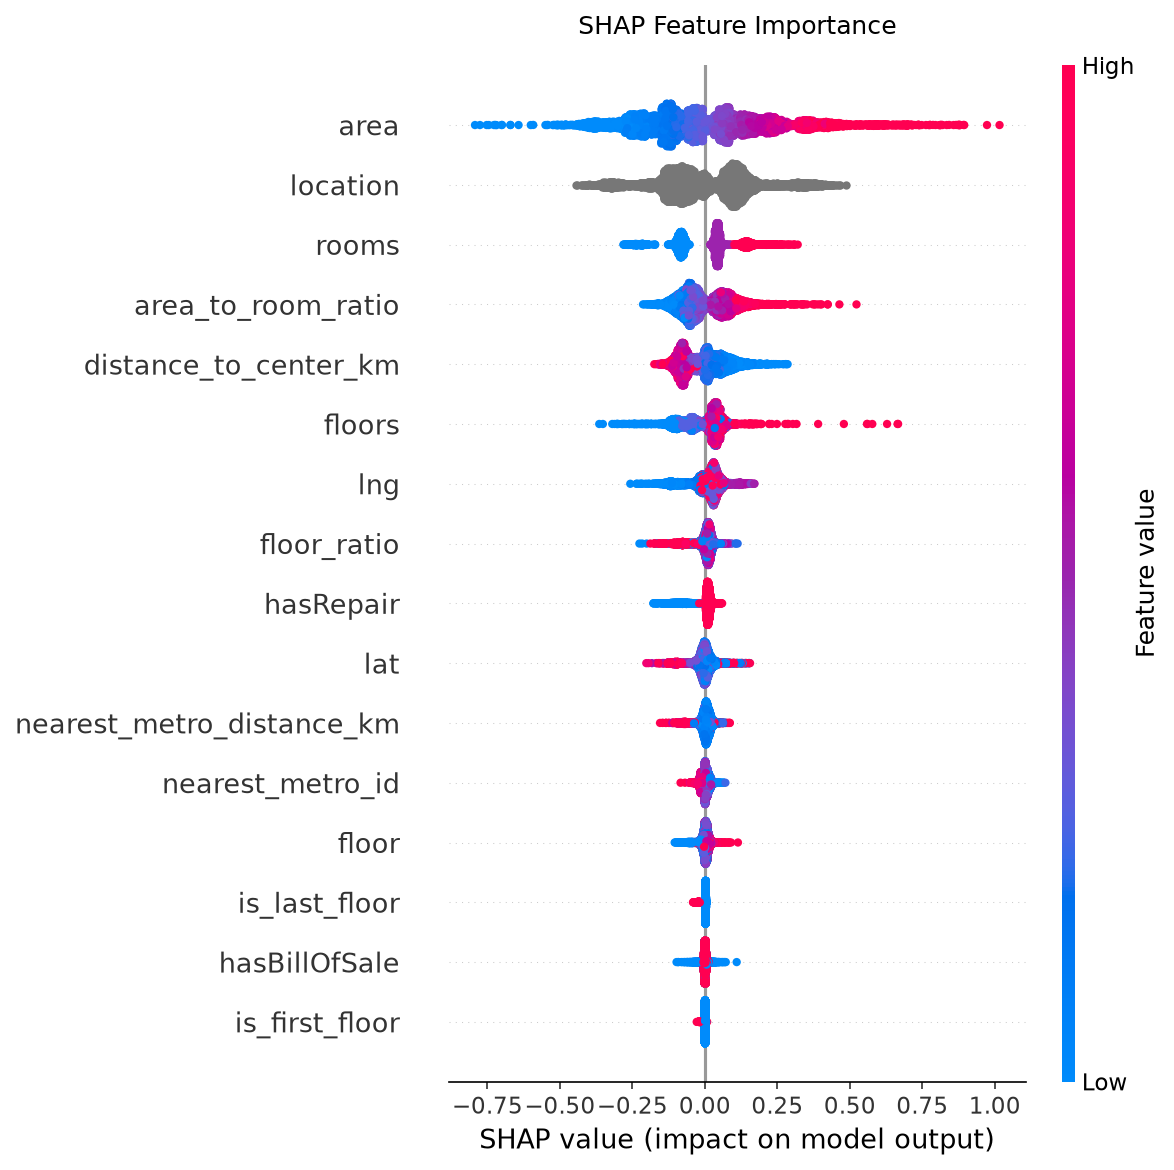

In [8]:
feature_importance_plot(best_lgbm, x_val)

In [9]:
val_analysis = x_val.copy()
val_analysis["actual_price"] = y_val.values
val_analysis["pred_price"] = pred_tuned
val_analysis["abs_error"] = np.abs(val_analysis["actual_price"] - val_analysis["pred_price"])
val_analysis["pct_error"] = (val_analysis["abs_error"] / val_analysis["actual_price"]) * 100

In [10]:
val_analysis.sort_values("pct_error", ascending=False)[
    ["actual_price", "pred_price", "pct_error", "area", "rooms", "location", "distance_to_center_km"]
].head(1000)

actual_price      pred_price   pct_error        area  rooms  \
38552        510000 1229372.9634923 141.0535223 240.0000000      3   
12468        172000  405764.4353113 135.9095554  78.0000000      3   
13675        185000  427463.3450608 131.0612676 100.0000000      2   
32058        110000  247099.9405759 124.6363096  96.0000000      3   
28671        300000  645220.6634877 115.0735545 132.0000000      4   
...             ...             ...         ...         ...    ...   
9291         370000  307839.8257334  16.8000471 131.4000000      4   
3790        1050000 1226336.6060707  16.7939625 249.0000000      4   
12758        190000  221902.7941404  16.7909443 100.0000000      2   
3641         178000  207853.1330533  16.7714231  80.0000000      2   
26484        640770  533356.3965439  16.7632073 120.9000000      3   

          location  distance_to_center_km  
38552        Sahil              0.6773203  
12468  İçəri Şəhər              0.1587296  
13675     Nardaran             27.7667561  
32058      Əhmədli             10.7150530  
28671     Ağ şəhər              5.1496288  
...            ...                    ...  
9291      Böyükşor              2.9300907  
3790        28 May              1.8645454  
12758      Gənclik              3.9216091  
3641         Bayıl              2.7806082  
26484        Sahil              0.8029888  

[1000 rows x 7 columns]

In [11]:
joblib.dump(best_lgbm, LOG_PATH / "lgbm.joblib")

['C:\\projects\\apartmentprices\\models\\lgbm.joblib']

In [12]:
# test set evaluation

test_df = pd.read_parquet(PROCESSED_DATA / "03_engineered_test.parquet")

test_df.head()

area           location   price  floor  floors  rooms  hasBillOfSale  \
0  80.0000000  Nəriman Nərimanov  247000      5       5      3           True   
1 162.0000000  Nəriman Nərimanov  430000      7      19      3           True   
2 113.0000000  Azadlıq Prospekti  355000      4      14      3           True   
3  65.0000000        İnşaatçılar  246000      7      14      2           True   
4  67.0000000          Bakıxanov  165000      5       6      2           True   

   hasRepair        lat        lng  floor_ratio  is_first_floor  \
0       True 40.4034615 49.8642883    1.0000000           False   
1       True 40.4048828 49.8705735    0.3684211           False   
2       True 40.4287865 49.8425516    0.2857143           False   
3       True 40.3859367 49.8035281    0.5000000           False   
4       True 40.4352076 49.9577609    0.8333333           False   

   is_last_floor  area_to_room_ratio  nearest_metro_distance_km  \
0           True          26.6666667                  0.5426978   
1          False          54.0000000                  0.2084017   
2          False          37.6666667                  0.3320260   
3          False          32.5000000                  0.5319041   
4          False          33.5000000                  2.7839714   

   nearest_metro_id  distance_to_center_km  
0                 4              4.8577757  
1                 4              5.2908012  
2                24              6.9480092  
3                17              3.3069102  
4                 8             13.0039179

In [14]:
X_test = test_df[best_lgbm.feature_name_].copy()
y_test = test_df["price"]

test_preds = np.expm1(best_lgbm.predict(X_test))

test_metrics = evaluate_predictions(y_test, test_preds, "LightGBM (Final Holdout Test)")

=== LightGBM (Final Holdout Test) ===
MAE:   26,754 AZN
MAPE:  8.01%
RMSLE: 0.1226
R²:    0.8821



In [15]:
log_experiment(
    model_name=test_metrics["Model"],
    dataset_version="Engineered Test",
    features_used=best_lgbm.feature_name_,
    metrics={k: v for k, v in test_metrics.items() if k != "model_name"},
    notes="FINAL HOLDOUT TEST EVALUATION (Untouched 20% test split)",
)

Logged to C:\projects\apartmentprices\models\experiments.csv


timestamp                          model             data  \
0   2026-09-07 18:40                  LGBMRegressor     Complete raw   
1   2026-09-07 18:40                  LGBMRegressor  Engineered Data   
2   2026-09-07 18:45                  LGBMRegressor  Engineered Data   
3   2026-09-07 18:48                  LGBMRegressor  Engineered Data   
4   2026-09-07 18:53              CatBoostRegressor  Engineered Data   
5   2026-09-07 18:58              CatBoostRegressor  Engineered Data   
6   2026-09-07 19:01        LightGBM (Optuna Tuned)  Engineered Data   
7   2026-09-08 01:17        LightGBM (Optuna Tuned)  Engineered Data   
8   2026-09-08 01:57                  LGBMRegressor  Engineered Data   
9   2026-09-08 01:57              CatBoostRegressor  Engineered Data   
10  2026-09-08 02:00        LightGBM (Optuna Tuned)  Engineered Data   
11  2026-09-08 02:12                  LGBMRegressor  Engineered Data   
12  2026-09-08 02:12              CatBoostRegressor  Engineered Data   
13  2026-09-08 02:15        LightGBM (Optuna Tuned)  Engineered Data   
14  2026-09-08 02:26  LightGBM (Final Holdout Test)  Engineered Test   

    n_features           mae       mape     rmsle        r2  \
0           10 38409.0000000 12.2000000 0.1621000 0.8611000   
1           12 35817.0000000 10.8100000 0.1487000 0.8616000   
2           16 34983.0000000 10.6100000 0.1461000 0.8685000   
3           16 29634.0000000  9.0900000 0.1292000 0.9047000   
4           16 32065.0000000  9.7700000 0.1349000 0.8926000   
5           16 32065.0000000  9.7700000 0.1349000 0.8926000   
6           16 26534.0000000  8.1800000 0.1211000 0.9194000   
7           16 26499.0000000  8.1200000 0.1210000 0.9156000   
8           16 29710.0000000  9.0900000 0.1294000 0.9018000   
9           16 32220.0000000  9.8000000 0.1358000 0.8877000   
10          16 26447.0000000  8.0900000 0.1207000 0.9126000   
11          16 29710.0000000  9.0900000 0.1294000 0.9018000   
12          16 32220.0000000  9.8000000 0.1358000 0.8877000   
13          16 26091.0000000  7.9800000 0.1199000 0.9148000   
14          16 26754.0000000  8.0100000 0.1226000 0.8821000   

                                                notes  
0           Baseline performance on complete raw data  
1                    First iteration complete dataset  
2                       2. iteration complete dataset  
3   2. iteration complete dataset with more powerf...  
4                             CatBoost on 16 features  
5                             CatBoost on 16 features  
6              Optuna tuned 60 trials minimizing MAPE  
7              Optuna tuned 60 trials minimizing MAPE  
8    Added area to room ratio and dropped hasMortgage  
9   CatBoost (Added area to room ratio and dropped...  
10  Optuna tuned 60 trials minimizing MAPE (Added ...  
11   Added area to room ratio and dropped hasMortgage  
12  CatBoost (Added area to room ratio and dropped...  
13  Optuna tuned 60 trials minimizing MAPE (Added ...  
14  FINAL HOLDOUT TEST EVALUATION (Untouched 20% t...

In [16]:
scoreboard = pd.read_csv(LOG_PATH / "experiments.csv")
scoreboard.sort_values("mape")

timestamp                          model             data  \
13  2026-09-08 02:15        LightGBM (Optuna Tuned)  Engineered Data   
14  2026-09-08 02:26  LightGBM (Final Holdout Test)  Engineered Test   
10  2026-09-08 02:00        LightGBM (Optuna Tuned)  Engineered Data   
7   2026-09-08 01:17        LightGBM (Optuna Tuned)  Engineered Data   
6   2026-09-07 19:01        LightGBM (Optuna Tuned)  Engineered Data   
8   2026-09-08 01:57                  LGBMRegressor  Engineered Data   
3   2026-09-07 18:48                  LGBMRegressor  Engineered Data   
11  2026-09-08 02:12                  LGBMRegressor  Engineered Data   
5   2026-09-07 18:58              CatBoostRegressor  Engineered Data   
4   2026-09-07 18:53              CatBoostRegressor  Engineered Data   
12  2026-09-08 02:12              CatBoostRegressor  Engineered Data   
9   2026-09-08 01:57              CatBoostRegressor  Engineered Data   
2   2026-09-07 18:45                  LGBMRegressor  Engineered Data   
1   2026-09-07 18:40                  LGBMRegressor  Engineered Data   
0   2026-09-07 18:40                  LGBMRegressor     Complete raw   

    n_features           mae       mape     rmsle        r2  \
13          16 26091.0000000  7.9800000 0.1199000 0.9148000   
14          16 26754.0000000  8.0100000 0.1226000 0.8821000   
10          16 26447.0000000  8.0900000 0.1207000 0.9126000   
7           16 26499.0000000  8.1200000 0.1210000 0.9156000   
6           16 26534.0000000  8.1800000 0.1211000 0.9194000   
8           16 29710.0000000  9.0900000 0.1294000 0.9018000   
3           16 29634.0000000  9.0900000 0.1292000 0.9047000   
11          16 29710.0000000  9.0900000 0.1294000 0.9018000   
5           16 32065.0000000  9.7700000 0.1349000 0.8926000   
4           16 32065.0000000  9.7700000 0.1349000 0.8926000   
12          16 32220.0000000  9.8000000 0.1358000 0.8877000   
9           16 32220.0000000  9.8000000 0.1358000 0.8877000   
2           16 34983.0000000 10.6100000 0.1461000 0.8685000   
1           12 35817.0000000 10.8100000 0.1487000 0.8616000   
0           10 38409.0000000 12.2000000 0.1621000 0.8611000   

                                                notes  
13  Optuna tuned 60 trials minimizing MAPE (Added ...  
14  FINAL HOLDOUT TEST EVALUATION (Untouched 20% t...  
10  Optuna tuned 60 trials minimizing MAPE (Added ...  
7              Optuna tuned 60 trials minimizing MAPE  
6              Optuna tuned 60 trials minimizing MAPE  
8    Added area to room ratio and dropped hasMortgage  
3   2. iteration complete dataset with more powerf...  
11   Added area to room ratio and dropped hasMortgage  
5                             CatBoost on 16 features  
4                             CatBoost on 16 features  
12  CatBoost (Added area to room ratio and dropped...  
9   CatBoost (Added area to room ratio and dropped...  
2                       2. iteration complete dataset  
1                    First iteration complete dataset  
0           Baseline performance on complete raw data